In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from matplotlib.gridspec import GridSpec

def bufferx_radius(pts, target_pct=100.0):
    """Calculates density-aware radius"""
    pts_torch = torch.from_numpy(pts[:, :3]).float()
    indices = torch.randperm(pts_torch.shape[0])[:1000]
    kpts = pts_torch[indices]
    dist_sqr = torch.cdist(kpts.unsqueeze(0), pts_torch.unsqueeze(0)).squeeze(0)**2
    
    low, high = 0.0, 500.0 
    for _ in range(40):
        r = (low + high) / 2.0
        avg_pct = ((dist_sqr < r**2).float().sum() / (pts_torch.shape[0] * 1000)) * 100
        if avg_pct < target_pct: low = r
        else: high = r
    return r

def bufferx_voxel(pts):
    """Determines adaptive voxel size based on PCA sphericity"""
    sample_idx = np.random.choice(len(pts), int(len(pts)/10), replace=False)
    sampled = pts[sample_idx]
    pca = PCA(n_components=3)
    pca.fit(sampled)
    eigenvalues = pca.explained_variance_
    sphericity = min(eigenvalues) / max(eigenvalues)
    transformed_pts = pca.transform(pts)
    z_range = transformed_pts[:, 2].max() - transformed_pts[:, 2].min()
    
    alpha = 1.0 if sphericity < 0.05 else 1.5
    v = (np.sqrt(z_range) / 100) * alpha
    return max(v, 0.001)

def voxel_downsample(pts, voxel_size):
    """Grid-based downsampling for comparable density"""
    coords = (pts[:, :3] / voxel_size).astype(int)
    unique_indices = {}
    for i, coord in enumerate(coords):
        key = tuple(coord)
        if key not in unique_indices: unique_indices[key] = i
    return pts[list(unique_indices.values())]

def render_comparison(ref_pts, src_pts, stage_name):
    """Renders combined and side-by-side views"""
    fig = plt.figure(figsize=(20, 10))
    gs = GridSpec(2, 6, figure=fig)
    angles = [(90, -90, "Top"), (0, -90, "Side"), (-90, -90, "Bottom")]

    all_pts = np.vstack([ref_pts, src_pts])
    max_range = np.max(np.abs(all_pts)) * 1.1
    lims = [-max_range, max_range]

    for i, (elev, azim, title) in enumerate(angles):
        ax_c = fig.add_subplot(gs[0, i*2 : i*2+2], projection='3d')
        ax_c.scatter(ref_pts[:, 0], ref_pts[:, 1], ref_pts[:, 2], c='red', s=1, alpha=0.3)
        ax_c.scatter(src_pts[:, 0], src_pts[:, 1], src_pts[:, 2], c='blue', s=1, alpha=0.3)
        ax_c.set_xlim(lims); ax_c.set_ylim(lims); ax_c.set_zlim(lims)
        ax_c.view_init(elev=elev, azim=azim)
        ax_c.set_title(f"Combined {title} ({stage_name})")
        
        for j, (data, color, name) in enumerate([(ref_pts, 'red', 'Ref'), (src_pts, 'blue', 'Plank')]):
            ax = fig.add_subplot(gs[1, i*2 + j], projection='3d')
            ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=color, s=1, alpha=0.5)
            ax.set_xlim(lims); ax.set_ylim(lims); ax.set_zlim(lims)
            ax.view_init(elev=elev, azim=azim)
            ax.set_title(f"{name} {title}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()


r_ref = 2.6902380454885133
r_plank = 2.223123403837235
Rendering: Just After Scaling...


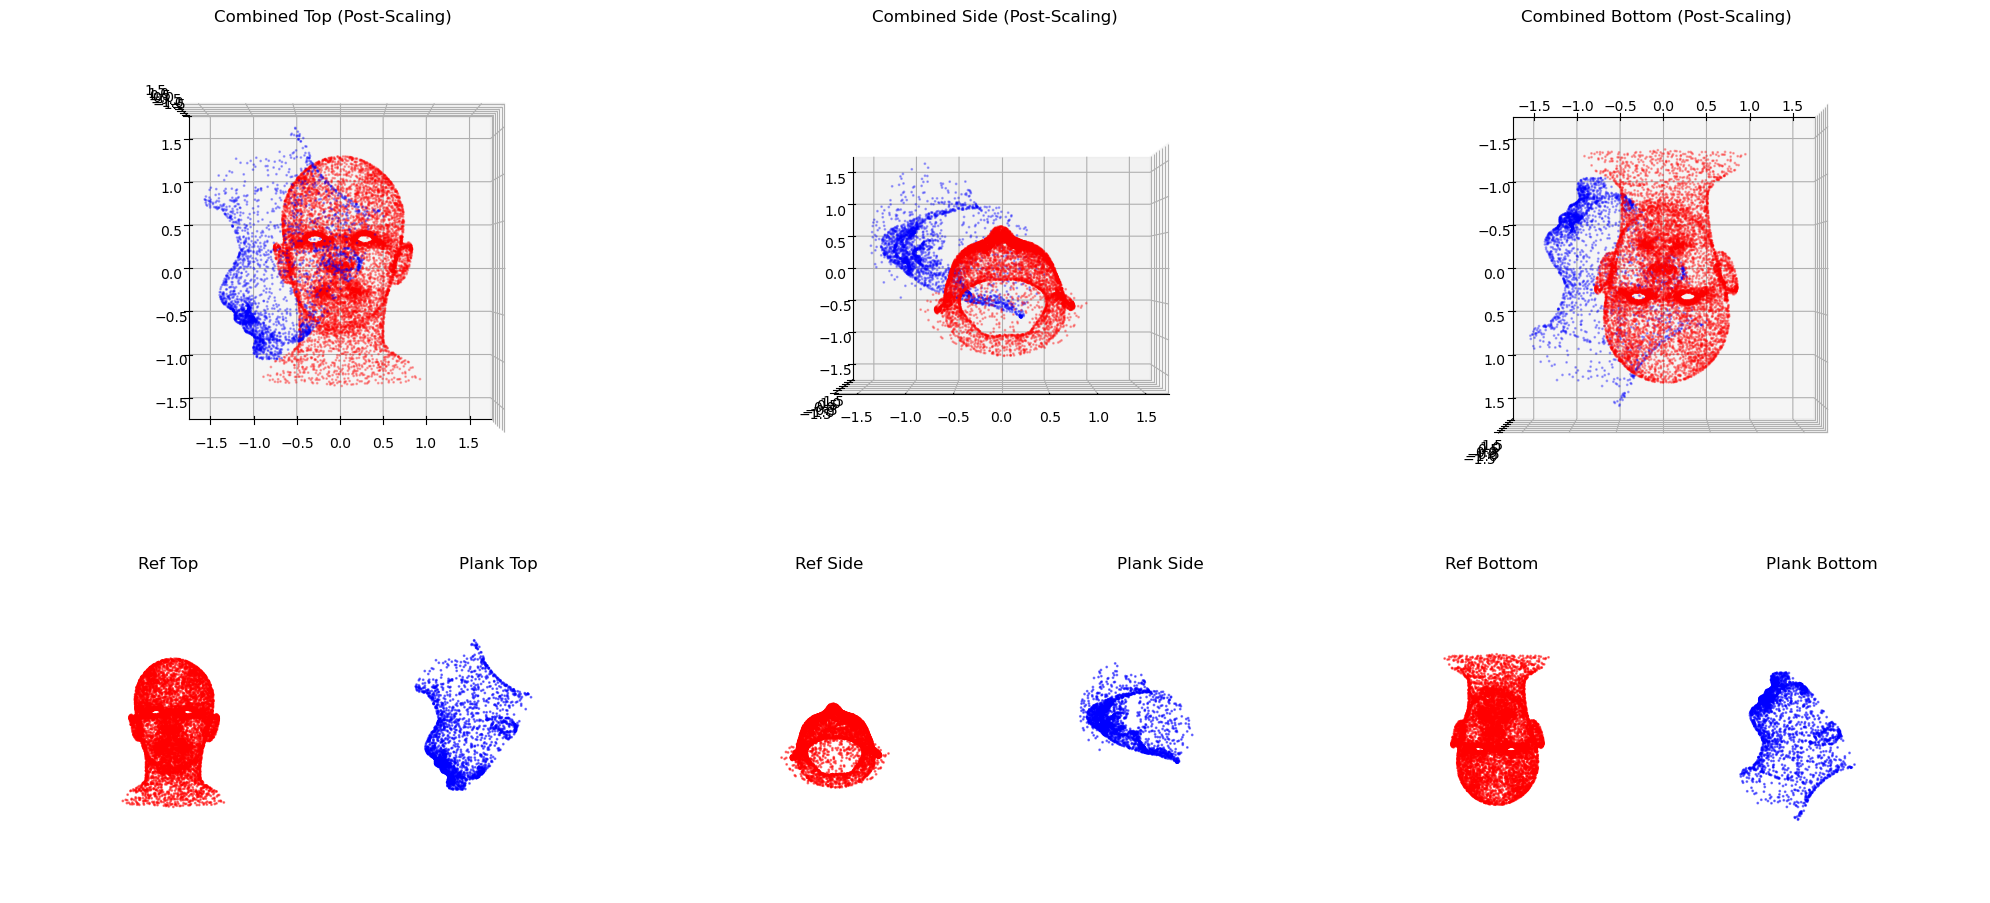

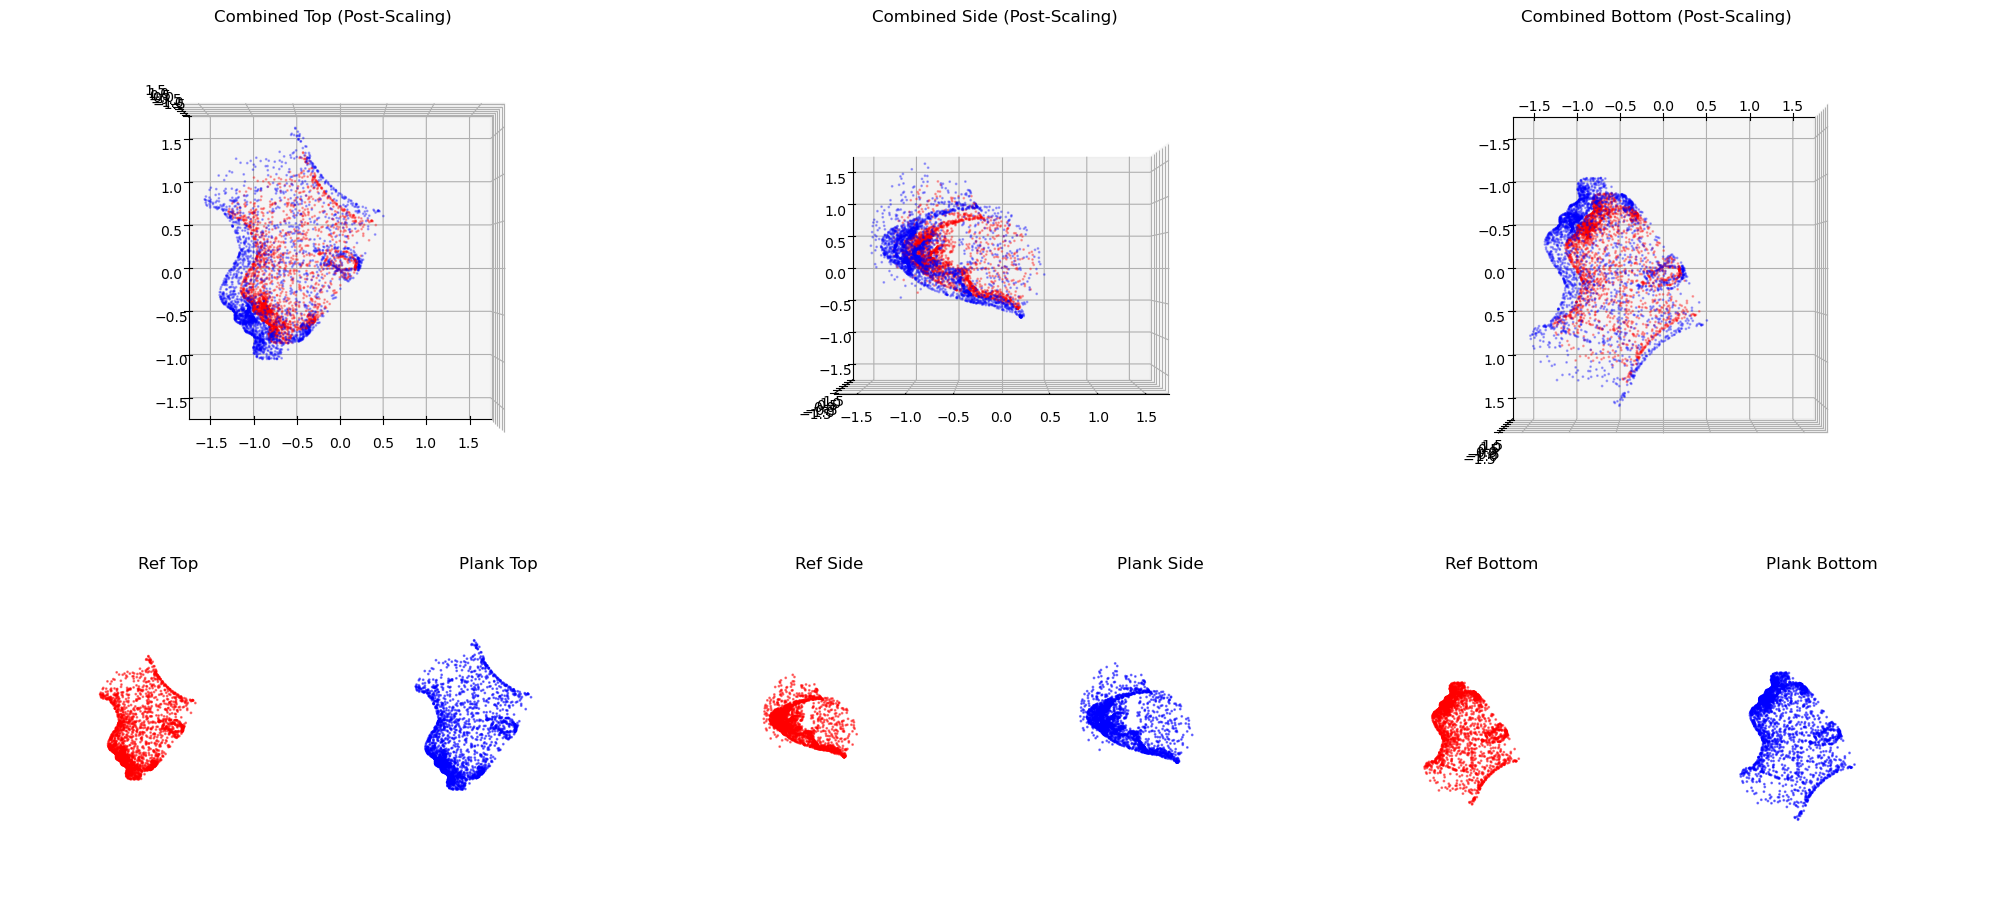

In [19]:
# Scale Alignment 
ref = np.load('ref.npy')[:, :3]
#plank = np.load('plank.npy')[:, :3]
plank = np.load("../../data/faces/demo/src_23.npy")[:, :3]
og = np.load("../../data/faces/demo/src_23.npy")[:, :3]
# Calculate radii to resolve scale discrepancies
r_ref = bufferx_radius(ref)
r_plank = bufferx_radius(plank)

print(f"r_ref = {r_ref}")
print(f"r_plank = {r_plank}")

# Normalize to unit scale
ref_norm = ref 
plank_norm = plank * r_ref / r_plank

np.save('scaled_ref.npy', ref_norm)
np.save('scaled_src.npy', plank_norm)

print("Rendering: Just After Scaling...")
render_comparison(ref_norm, plank_norm, "Post-Scaling")
render_comparison(og, plank_norm, "Post-Scaling")




Ref-calculated Voxel Size: 0.0404
Rendering: After Voxelization (using Ref Voxel Size)...


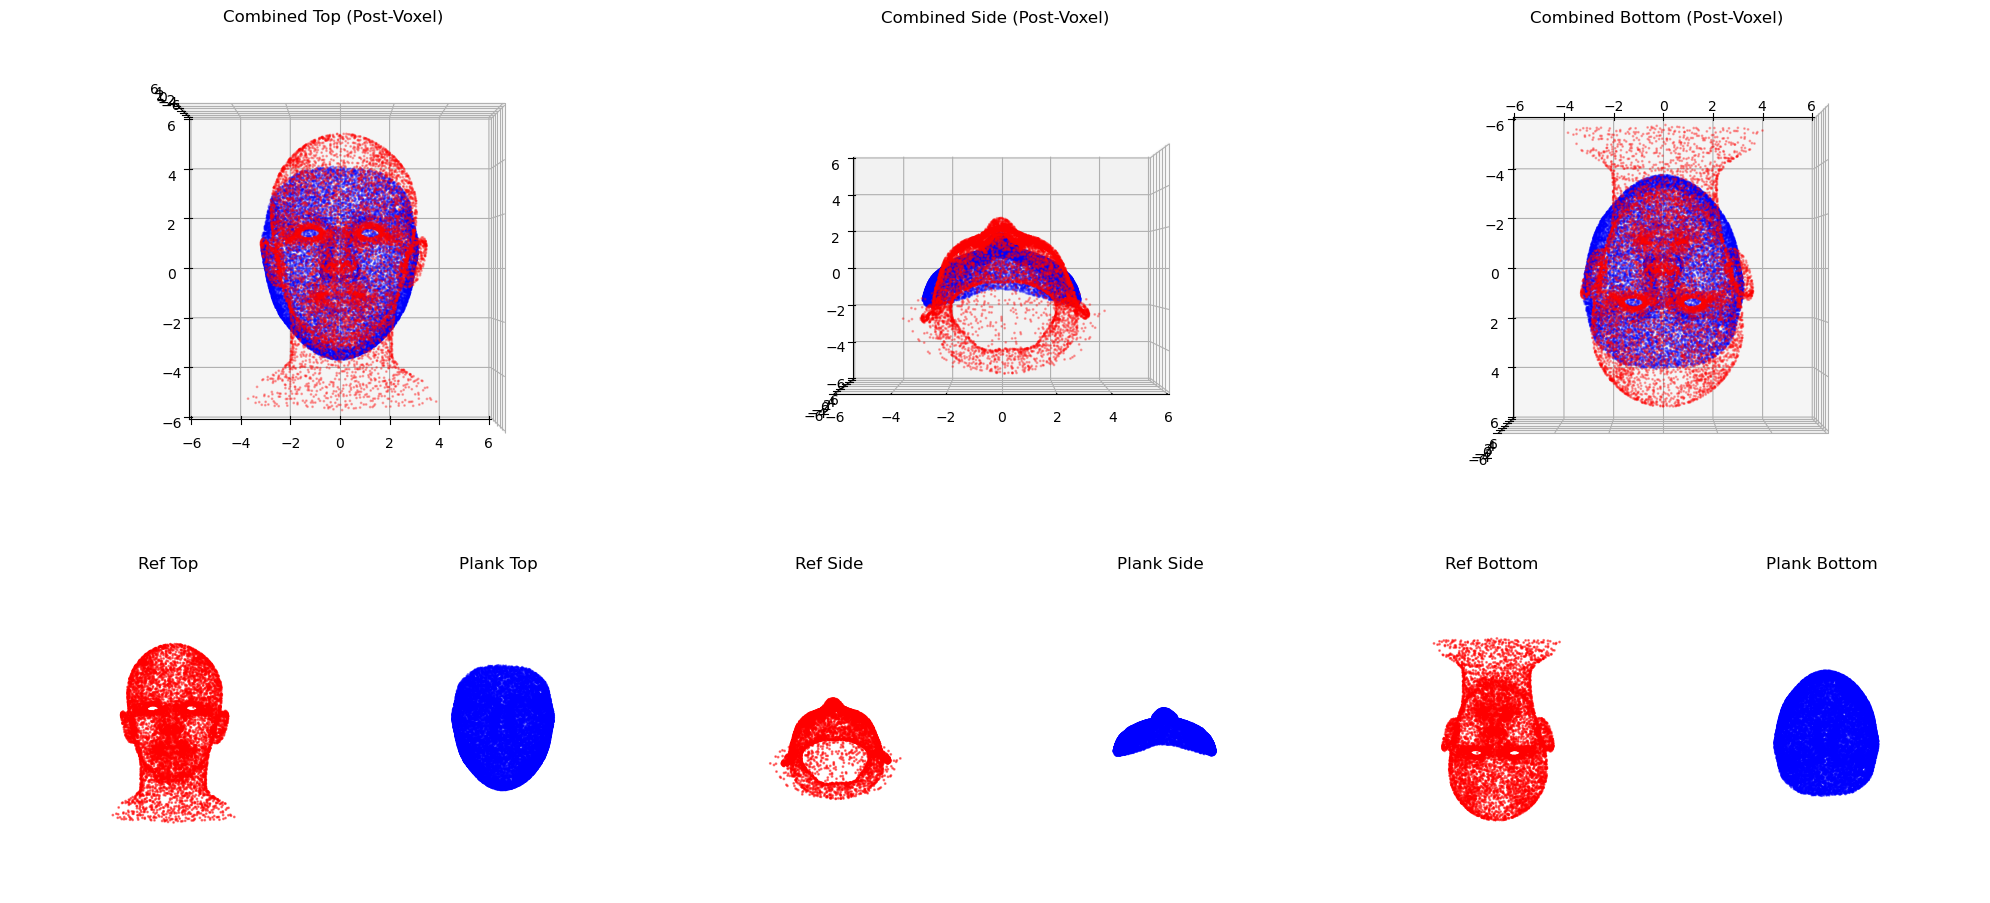

In [40]:
# Voxelization using REF Voxel Size

v_ref_only = bufferx_voxel(ref_norm)
print(f"Ref-calculated Voxel Size: {v_ref_only:.4f}")

# Apply ref-based voxel size to both 
ref_v = voxel_downsample(ref_norm, v_ref_only)
src_v = voxel_downsample(plank_norm, v_ref_only)

print("Rendering: After Voxelization (using Ref Voxel Size)...")
render_comparison(ref_v, src_v, "Post-Voxel")

Point count - Scaled Source (Full): 20000
Point count - Voxelized Source (Downsampled): 15720


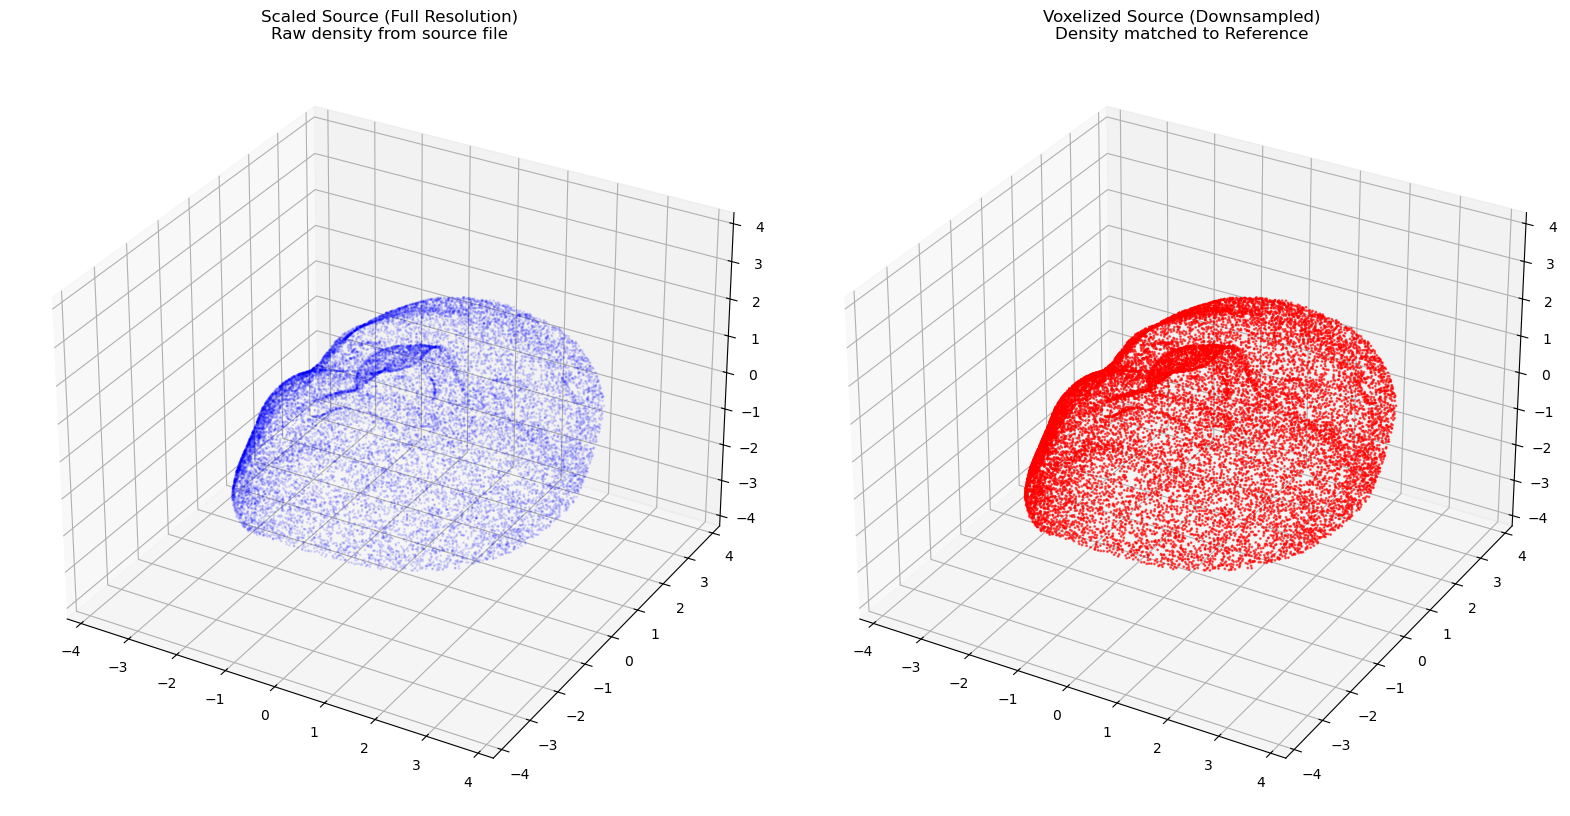

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Print Point Counts
print(f"Point count - Scaled Source (Full): {len(scaled_src)}")
print(f"Point count - Voxelized Source (Downsampled): {len(src_v)}")

# Side-by-Side Plot
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, figure=fig)

all_points = np.vstack([scaled_src, src_v])
max_range = np.max(np.abs(all_points)) * 1.1
lims = [-max_range, max_range]

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax1.scatter(scaled_src[:, 0], scaled_src[:, 1], scaled_src[:, 2], c='blue', s=1, alpha=0.1)
ax1.set_xlim(lims); ax1.set_ylim(lims); ax1.set_zlim(lims)
ax1.view_init(elev=30, azim=-60)
ax1.set_title("Scaled Source (Full Resolution)\nRaw density from source file")

ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax2.scatter(src_v[:, 0], src_v[:, 1], src_v[:, 2], c='red', s=1, alpha=0.6)
ax2.set_xlim(lims); ax2.set_ylim(lims); ax2.set_zlim(lims)
ax2.view_init(elev=30, azim=-60)
ax2.set_title("Voxelized Source (Downsampled)\nDensity matched to Reference")

plt.tight_layout()
plt.show()

In [42]:
print("scaled-src calculated Voxel Size:", bufferx_voxel(scaled_src))
print("src_v calculated Voxel Size:", bufferx_voxel(src_v))
print("ref_v calculated Voxel Size:", bufferx_voxel(ref_v))


scaled-src calculated Voxel Size: 0.029046577483860022
src_v calculated Voxel Size: 0.028734585139331123
ref_v calculated Voxel Size: 0.04030940145272388


In [43]:
print("scaled ref calculated r:", bufferx_radius(ref_norm))
print("scaled src calculated r:", bufferx_radius(plank_norm))

scaled ref calculated r: 0.9798602009141177
scaled src calculated r: 0.9918803693835798


In [23]:
import torch
import numpy as np
import open3d as o3d

def get_bufferx_scale_and_patches(pts_p, pts_q, target_pct=0.01, num_patches=50):
    """
    Implements BUFFER-X adaptive radius and patch-wise normalization.
    pts_p, pts_q: numpy arrays (N, 3)
    target_pct: tau_xi (desired neighborhood density)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Identify the larger cloud based on cardinality [cite: 163]
    p_torch = torch.from_numpy(pts_p[:, :3]).float().to(device)
    q_torch = torch.from_numpy(pts_q[:, :3]).float().to(device)
    ref_cloud = p_torch if p_torch.shape[0] > q_torch.shape[0] else q_torch [cite: 163]
    
    # 2. Geometric Bootstrapping: Calculate Density-Aware Radius (Equation 5)
    # We sample N_r points to estimate the radius [cite: 184]
    indices = torch.randperm(ref_cloud.shape[0])[:1000]
    query_pts = ref_cloud[indices]
    
    # Binary search for radius r 
    low, high = 0.01, 100.0
    r = 1.0
    for _ in range(30):
        r = (low + high) / 2.0
        # Calculate average proportion of neighbors [cite: 182, 184]
        dists = torch.cdist(query_pts, ref_cloud)
        avg_pct = (dists < r).float().sum() / (query_pts.shape[0] * ref_cloud.shape[0])
        
        if avg_pct < target_pct: low = r
        else: high = r
    
    print(f"Calculated Adaptive Radius (r): {r:.4f}m")

    # 3. Patch-wise Scale Normalization [cite: 110, 209]
    def extract_normalized_patches(cloud, num_kpts, radius):
        # Sample keypoints (Paper uses Farthest Point Sampling) [cite: 203]
        k_indices = torch.randperm(cloud.shape[0])[:num_kpts]
        keypoints = cloud[k_indices]
        
        normalized_patches = []
        for i in range(num_kpts):
            center = keypoints[i]
            # Find neighbors within radius r [cite: 179]
            dists = torch.norm(cloud - center, dim=1)
            mask = dists < radius
            patch = cloud[mask]
            
            # Normalize: Center the patch and divide by radius 
            # This maps points to the range [-1, 1] [cite: 110, 209]
            norm_patch = (patch - center) / radius
            normalized_patches.append(norm_patch.cpu().numpy())
            
        return normalized_patches

    patches_p = extract_normalized_patches(p_torch, num_patches, r)
    patches_q = extract_normalized_patches(q_torch, num_patches, r)
    
    return patches_p, patches_q, r

def render_normalized_clouds(patches_p, patches_q):
    """Renders all normalized patches together at the origin to show scale alignment."""
    vis_p = o3d.geometry.PointCloud()
    vis_q = o3d.geometry.PointCloud()
    
    # Combine all patches into two clouds for visualization
    all_p = np.concatenate(patches_p, axis=0)
    all_q = np.concatenate(patches_q, axis=0)
    
    vis_p.points = o3d.utility.Vector3dVector(all_p)
    vis_p.paint_uniform_color([1, 0, 0]) # Red for P
    
    vis_q.points = o3d.utility.Vector3dVector(all_q)
    vis_q.paint_uniform_color([0, 0, 1]) # Blue for Q
    
    # Add a unit sphere wireframe to show the [-1, 1] boundary 
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=1.0, resolution=20)
    sphere = o3d.geometry.LineSet.create_from_triangle_mesh(sphere)
    sphere.paint_uniform_color([0.5, 0.5, 0.5])

    o3d.visualization.draw_geometries([vis_p, vis_q, sphere], 
                                      window_name="BUFFER-X Scale Normalization")
    
def render_patches_in_grid(patches_p, patches_q, grid_size=5):
    """Renders patches in a grid so they don't overlap into a ball."""
    offset = 2.5 # Distance between patches in the grid
    geometries = []

    for i in range(min(len(patches_p), grid_size**2)):
        # Calculate grid position
        x_off = (i % grid_size) * offset
        y_off = (i // grid_size) * offset
        
        # Source Patch (Red)
        p_mesh = o3d.geometry.PointCloud()
        p_mesh.points = o3d.utility.Vector3dVector(patches_p[i] + np.array([x_off, y_off, 0]))
        p_mesh.paint_uniform_color([1, 0, 0])
        
        # Target Patch (Blue) - moved slightly to the right of the Red one
        q_mesh = o3d.geometry.PointCloud()
        q_mesh.points = o3d.utility.Vector3dVector(patches_q[i] + np.array([x_off + 1.2, y_off, 0]))
        q_mesh.paint_uniform_color([0, 0, 1])
        
        geometries.extend([p_mesh, q_mesh])

    o3d.visualization.draw_geometries(geometries, window_name="BUFFER-X Standardized Patches")

ref = np.load('ref.npy')[:, :3]
#plank = np.load('plank.npy')[:, :3]
plank = np.load("../../data/faces/demo/src_23.npy")[:, :3]
# Usage
p_patches, q_patches, final_r = get_bufferx_scale_and_patches(ref, plank)
render_patches_in_grid(p_patches, q_patches)

Calculated Adaptive Radius (r): 0.0807m
